In [20]:
import os
import glob

import numpy as np
from datetime import timedelta

import xarray as xr

import matplotlib.pyplot as plt

from parcels import (AdvectionRK4_3D,
                     AdvectionRK4,
                     FieldSet,
                     StatusCode,
                     JITParticle,
                     ParticleSet)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [13]:
datapath_in = '/silod7/ramos/Oder/MOM_ERGOM/'

datapath_out = '/silod7/ramos/Golden/'

velfilename = '20220101.ocean_month_2022_08.nc'

trajfilename ='connect_20July_mais_particles.zarr'

# gridtype of input data ('A' or 'C')
gridtype = 'C'

# timestep of input data in seconds (here: hourly)
times_convert = 3600 #

In [ ]:
import numpy as np

# --- Release timing ---
release_time = 456

# --- Polish side (east) ---
pl_lonmin, pl_lonmax = 14.51, 14.54
pl_latmin, pl_latmax = 53.675, 53.7

# --- German side (Kleines Haff - KHM) ---
de_lonmin, de_lonmax = 14.1, 14.12
de_latmin, de_latmax = 53.8, 53.83

# --- Grid resolution (degrees) ---
release_dx = 0.0001  

# --- Function to make lon/lat grids for a box ---
def make_release_grid(lonmin, lonmax, latmin, latmax, dx):
    lon_vals = np.arange(lonmin, lonmax + dx, dx)
    lat_vals = np.arange(latmin, latmax + dx, dx)
    lons, lats = np.meshgrid(lon_vals, lat_vals)    
    return lons, lats   # keep 2D grids!


# --- Generate both sides ---
lons_pl, lats_pl = make_release_grid(pl_lonmin, pl_lonmax, pl_latmin, pl_latmax, release_dx)
lons_de, lats_de = make_release_grid(de_lonmin, de_lonmax, de_latmin, de_latmax, release_dx)

# --- Summary ---
release_pl = lons_pl.size
release_de = lons_de.size
print(f"Total release positions (Polish): {release_pl}")
print(f"Total release positions (German): {release_de}")

Total release positions (Polish): 75852
Total release positions (German): 60702


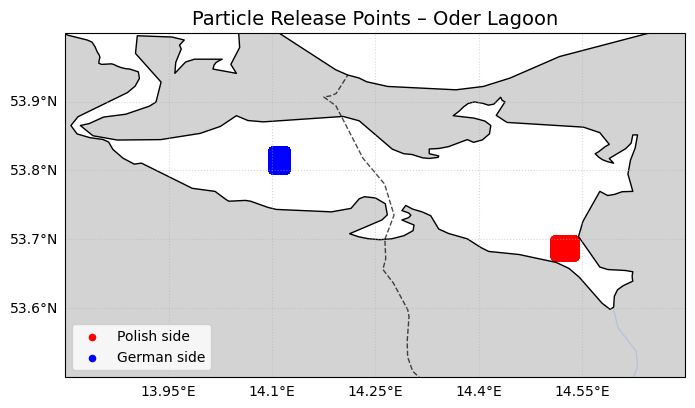

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Create a map ---
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle="--", alpha=0.7)
ax.add_feature(cfeature.RIVERS, alpha=0.5)

# --- Polish side (red) ---
ax.scatter(lons_pl.flatten(), lats_pl.flatten(),
           s=20, color='red', label='Polish side',
           transform=ccrs.PlateCarree())

# --- German side (blue) ---
ax.scatter(lons_de.flatten(), lats_de.flatten(),
           s=20, color='blue', label='German side',
           transform=ccrs.PlateCarree())

# --- Map extent ---
ax.set_extent([13.8, 14.7, 53.5, 54.0], crs=ccrs.PlateCarree())

ax.set_title("Particle Release Points – Oder Lagoon", fontsize=14)
ax.legend(loc="lower left")

# Optional gridlines
gl = ax.gridlines(draw_labels=True, linestyle=":", alpha=0.5)
gl.top_labels = gl.right_labels = False

plt.show()


In [ ]:
# total integration time in hours
tint = 753 #(run for 1 month)

# set frequency with which to output particle data in minutes
outdt = 60

# integration time step in minutes
intdt = 2

# particle class
# can be JITParticle or ScipyParticle
# (if possible use JITParticle)
pclass = JITParticle

In [ ]:
def create_fieldset(gridtype, datapath_in=datapath_in, velfilename=velfilename):
    """
    Create a Parcels FieldSet from MOM6 or GETM datasets.
    Interpolates velocities to cell centers if needed and uses from_netcdf.
    """
    velfiledir = datapath_in + velfilename

    if gridtype == 'C':
        # Paths to interpolated velocity files (assumes u_centered.nc and v_centered.nc exist)
        filenames = {
            'U': [
                datapath_in + '20220101.ocean_month_2022_07.nc',
                datapath_in + '20220101.ocean_month_2022_08.nc'
            ],
            'V': [
                datapath_in + '20220101.ocean_month_2022_07.nc',
                datapath_in + '20220101.ocean_month_2022_08.nc'
            ]
        }

        # Variable names in the NetCDF files
        variables = {'U': 'u', 'V': 'v'}

        # Dimensions in the NetCDF files
        dimensions = {
            'U': {'lon': 'xq', 'lat': 'yh', 'depth': 'zl', 'time': 'time'},
            'V': {'lon': 'xh', 'lat': 'yq', 'depth': 'zl', 'time': 'time'}
        }

        # Create the FieldSet using from_netcdf
        fieldset = FieldSet.from_netcdf(
            filenames, variables, dimensions,
            mesh='spherical',
            allow_time_extrapolation=False,
            deferred_load=True
        )

    elif gridtype == 'A':
        # Original A-grid code for GETM
        filenames = {
            'U': {'lon': velfiledir, 'lat': velfiledir, 'depth': velfiledir, 'data': velfiledir},
            'V': {'lon': velfiledir, 'lat': velfiledir, 'depth': velfiledir, 'data': velfiledir}
        }
        variables = {'U': 'uu', 'V': 'vv'}
        dimensions = {
            'U': {'lon': 'lonc', 'lat': 'latc', 'depth': 'level', 'time': 'time'},
            'V': {'lon': 'lonc', 'lat': 'latc', 'depth': 'level', 'time': 'time'}
        }
        indices = {'depth': [0, 1]}

        fieldset = FieldSet.from_a_grid_dataset(
            filenames, variables, dimensions,
            indices=indices,
            mesh='spherical',
            allow_time_extrapolation=False,
            time_periodic=False,
            deferred_load=True
        )

    else:
        raise ValueError("Unsupported gridtype. Use 'A' or 'C'.")

    return fieldset

In [ ]:
def create_run_particles(fieldset, output_filename,
                         times=release_time,
                         lons_pl=lons_pl, lats_pl=lats_pl,
                         lons_de=lons_de, lats_de=lats_de,
                         datapath_out=datapath_out,
                         integration_dt=intdt, runtime=tint,
                         output_dt=outdt):

    # Convert timestep index to actual datetime
    release_datetime = fieldset.U.grid.time[times]
  
    # --- time grids for each area ---
    times_pl = np.full_like(lons_pl, release_datetime)
    times_de = np.full_like(lons_de, release_datetime)

    # --- now flatten EVERYTHING but keep areas separate ---
    init_lon = np.concatenate([lons_pl.flatten(), lons_de.flatten()])
    init_lat = np.concatenate([lats_pl.flatten(), lats_de.flatten()])
    init_time = np.concatenate([times_pl.flatten(), times_de.flatten()])

    # --- create particle set ---
    pset = ParticleSet.from_list(
        fieldset=fieldset,
        pclass=pclass,
        lon=init_lon,
        lat=init_lat,
        time=init_time
    )

    output_file = pset.ParticleFile(
        name=datapath_out + output_filename,
        outputdt=timedelta(minutes=output_dt),
    )

    kernels = pset.Kernel(AdvectionRK4) 

    pset.execute(
       kernels,
        runtime=timedelta(hours=runtime),
        dt=timedelta(minutes=integration_dt),
        output_file=output_file,
        verbose_progress=True,
    )

In [21]:
fieldset = create_fieldset(gridtype, datapath_in, velfilename) 

In [22]:
create_run_particles(fieldset = fieldset,
                     output_filename = trajfilename)

INFO: Output files are stored in /silod7/ramos/Golden/connect_20July_mais_particles.zarr.
100%|██████████| 2710800.0/2710800.0 [51:06<00:00, 884.09it/s] 
